- DIA on ViT model 

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


- Core ViT model for gray images (channel = 1)

In [9]:
# ============================================================
# HFFH_ViT: Hybrid Freehand Imaging ViT (MobileViT-style)
# Approximation faithful to the printed architecture you gave
# Input:  (B, 1, H, W)
# Output: (B, 1, H, W)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- Core transformer components ----------

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x):
        # x: (B, N, dim)
        return self.fn(self.norm(x))


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=8, dropout=0.0):
        """
        dim: token embedding dim (8 or 16 in HFFH_ViT)
        heads: 4, so 3 * heads * dim_head = 96 = to_qkv out_features
        dim_head: 8
        """
        super().__init__()
        inner_dim = dim_head * heads * 3  # for q, k, v
        self.heads = heads
        self.dim_head = dim_head

        self.to_qkv = nn.Linear(dim, inner_dim, bias=False)
        self.attend = nn.Softmax(dim=-1)
        self.to_out = nn.Sequential(
            nn.Linear(dim_head * heads, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        """
        x: (B, N, dim)
        """
        b, n, _ = x.shape
        qkv = self.to_qkv(x)  # (B, N, 3 * heads * dim_head)
        qkv = qkv.view(b, n, 3, self.heads, self.dim_head)
        q, k, v = qkv.unbind(dim=2)  # each: (B, N, heads, dim_head)

        # (B, heads, N, dim_head)
        q = q.permute(0, 2, 1, 3)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)

        scale = self.dim_head ** -0.5
        dots = torch.matmul(q, k.transpose(-1, -2)) * scale  # (B, heads, N, N)
        attn = self.attend(dots)
        out = torch.matmul(attn, v)                           # (B, heads, N, dim_head)

        # (B, N, heads * dim_head)
        out = out.permute(0, 2, 1, 3).contiguous().view(b, n, self.heads * self.dim_head)
        out = self.to_out(out)  # (B, N, dim)
        return out


class Transformer(nn.Module):
    def __init__(self, dim, depth, mlp_dim, heads=4, dim_head=8, dropout=0.0):
        """
        dim: token dimension (8 or 16)
        depth: number of transformer layers
        mlp_dim: hidden dim in FFN (paper uses ~2x or 4x)
        """
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads=heads, dim_head=dim_head, dropout=dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout=dropout)),
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = x + attn(x)
            x = x + ff(x)
        return x


# ---------- MobileViT-style blocks ----------

class MV2Block(nn.Module):
    """
    MobileNetV2-style depthwise separable block.
    Matches the printed pattern:
      Conv2d(C,C,3x3,groups=C) -> BN -> SiLU -> Conv2d(C,C or C->C') -> BN
    With residual if in==out and stride==1.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride,
                      padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.use_res_connect = (stride == 1 and in_channels == out_channels)

    def forward(self, x):
        out = self.conv(x)
        if self.use_res_connect:
            out = out + x
        return out

class MobileViTBlock(nn.Module):
    """
    MobileViT-style block:
      conv1: 3x3 (C->C)
      conv2: 1x1 (C->transformer_dim)
      transformer over patches in token dim = transformer_dim
      conv3: 1x1 (transformer_dim->C)
      conv4: 3x3 on concat(local, global) (2C->C)

    patch_size controls how big each transformer patch is (e.g., (2,2) or (4,4)).
    """
    def __init__(self, in_channels, transformer_dim, depth,
                 patch_size=(2, 2), mlp_dim=None, heads=4, dim_head=8, dropout=0.0):
        super().__init__()
        ph, pw = patch_size
        self.patch_h = ph
        self.patch_w = pw
        self.transformer_dim = transformer_dim

        # Local conv
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
        )

        # Channel projection: C -> transformer_dim (8 or 16)
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels, transformer_dim, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(transformer_dim),
            nn.SiLU(inplace=False),
        )

        if mlp_dim is None:
            mlp_dim = transformer_dim * 2  # you can change to *4 if you want to mimic 4x layers

        self.transformer = Transformer(
            dim=transformer_dim,
            depth=depth,
            mlp_dim=mlp_dim,
            heads=heads,
            dim_head=dim_head,
            dropout=dropout,
        )

        # Back to conv space: transformer_dim -> in_channels
        self.conv3 = nn.Sequential(
            nn.Conv2d(transformer_dim, in_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
        )

        # Fuse local+global: (2C -> C)
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels * 2, in_channels, kernel_size=3, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
        )

    def forward(self, x):
        # x: (B, C, H, W)
        local_x = self.conv1(x)
        y = self.conv2(local_x)   # (B, transformer_dim, H, W)
        B, C, H, W = y.shape
        assert C == self.transformer_dim

        ph, pw = self.patch_h, self.patch_w

        # Pad so H,W divisible by patch size
        pad_h = (ph - H % ph) % ph
        pad_w = (pw - W % pw) % pw
        if pad_h != 0 or pad_w != 0:
            y = F.pad(y, (0, pad_w, 0, pad_h), mode="reflect")
            B, C, H, W = y.shape

        self._orig_hw = (H, W)

        # Unfold into non-overlapping patches
        # y_unfold: (B, C*ph*pw, L)
        y_unfold = F.unfold(y, kernel_size=(ph, pw), stride=(ph, pw))
        # reshape to (B, C, ph*pw, L) then average over patch pixels -> (B, C, L)
        y_unfold = y_unfold.view(B, C, ph * pw, -1).mean(dim=2)
        # tokens: (B, L, C)
        tokens = y_unfold.permute(0, 2, 1).contiguous()

        # Transformer over tokens
        tokens = self.transformer(tokens)  # (B, L, C)

        # Map tokens back to patches, broadcast to ph*pw pixels, fold back
        t = tokens.permute(0, 2, 1)                 # (B, C, L)
        t = t.unsqueeze(2).repeat(1, 1, ph * pw, 1) # (B, C, ph*pw, L)
        t = t.view(B, C * ph * pw, -1)              # (B, C*ph*pw, L)
        y = F.fold(t, output_size=(H, W), kernel_size=(ph, pw), stride=(ph, pw))

        # Crop to original (if we padded)
        orig_H, orig_W = self._orig_hw
        y = y[:, :, :orig_H, :orig_W]

        # Project back and fuse with local conv features
        y = self.conv3(y)
        out = torch.cat((x, y), dim=1)
        out = self.conv4(out)
        return out

# ---------- HFFH_ViT full network ----------

class HFFH_ViT(nn.Module):
    """
    Hybrid Freehand Imaging ViT
    - Input:  (B, 1, H, W)
    - Output: (B, 1, H, W)
    Matches the high-level structure you pasted:
      conv1: 1->16
      stem:  4x MV2Block(16->16)
      trunk:
        Stage1: MV2(16->16) + MobileViTBlock(16,8,depth=2)
        Stage2: MV2(16->16) + MobileViTBlock(16,8,depth=4)
        Stage3: MV2(16->32) + MobileViTBlock(32,16,depth=3)
      head:  1x1 conv 32->1
    """
    def __init__(self, img_channels=1, patch_size=(2, 2), dropout=0.0):
        super().__init__()

        # Initial conv: 1 -> 16
        self.conv1 = nn.Sequential(
            nn.Conv2d(img_channels, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.SiLU(inplace=False),
        )

        # Stem: 4× MV2Block(16->16)
        self.stem = nn.ModuleList([
            MV2Block(16, 16, stride=1),
            MV2Block(16, 16, stride=1),
            MV2Block(16, 16, stride=1),
            MV2Block(16, 16, stride=1),
        ])

        # Trunk: 3 stages
        self.trunk = nn.ModuleList()

        # Stage 1: channels 16, transformer_dim=8, depth=2 (as in printout)
        stage1 = nn.ModuleList([
            MV2Block(16, 16, stride=1),
            MobileViTBlock(
                in_channels=16,
                transformer_dim=8,
                depth=2,
                patch_size=patch_size,
                mlp_dim=16,      # 2x expansion for dim=8
                heads=4,
                dim_head=8,
                dropout=dropout,
            )
        ])
        self.trunk.append(stage1)

        # Stage 2: channels 16, transformer_dim=8, depth=4
        stage2 = nn.ModuleList([
            MV2Block(16, 16, stride=1),
            MobileViTBlock(
                in_channels=16,
                transformer_dim=8,
                depth=4,
                patch_size=patch_size,
                mlp_dim=32,      # 4x expansion for dim=8
                heads=4,
                dim_head=8,
                dropout=dropout,
            )
        ])
        self.trunk.append(stage2)

        # Stage 3: MV2 16->32, transformer_dim=16, depth=3
        stage3 = nn.ModuleList([
            MV2Block(16, 32, stride=1),
            MobileViTBlock(
                in_channels=32,
                transformer_dim=16,
                depth=3,
                patch_size=patch_size,
                mlp_dim=64,      # 4x expansion for dim=16
                heads=4,
                dim_head=8,
                dropout=dropout,
            )
        ])
        self.trunk.append(stage3)

        # ------------------ Lhamo: grayscale but SiLU negative values
        '''
        # Head: 32 -> 1
        self.condense_channels = nn.Sequential(
            nn.Sequential(
                nn.Conv2d(32, 1, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(1),
                nn.SiLU(inplace=False),
            )
        )
        '''
        # ------------------ Lhamo: ReLU For positive output pixel
        self.condense_channels = nn.Sequential(
            nn.Conv2d(32, 1, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(1),
            nn.ReLU(inplace=False),
            )

    def forward(self, x):
        # x: (B,1,H,W)
        x = self.conv1(x)  # (B,16,H,W)

        for block in self.stem:
            x = block(x)    # (B,16,H,W)

        # Trunk stages
        for stage in self.trunk:
            mv2, mvblock = stage
            x = mv2(x)
            x = mvblock(x)

        # Now 32 channels -> 1
        out = self.condense_channels(x)
        return out


- Matched Filter Algorithm (differentiable)

In [10]:
#======================================= MFA definitions
@dataclass
class MFAParams:
    F0: float          # start freq (Hz), e.g. 77e9
    c0: float          # lightspeed, e.g. 3e8
    dx: float          # mm
    dy: float          # mm
    z0_mm: float       # target range (mm)
    bbox: tuple        # (xmin, xmax, ymin, ymax) in mm
    FS: float          # sampling rate (Hz)
    K0: float          # chirp slope (Hz/s)
    tI: float          # instrument delay (s)
    nFFTtime: int      # range FFT size, e.g. 1024
    nFFTspace: int     # spatial FFT size, e.g. 1024


def build_matched_filter(params: MFAParams, device, dtype):
    """
    PyTorch version of refMF(params) in MATLAB.
    Returns: matchedFilter (nFFTspace x nFFTspace), complex tensor.
    """
    nF = params.nFFTspace
    dx_m = params.dx * 1e-3
    dy_m = params.dy * 1e-3
    z0_m = params.z0_mm * 1e-3

    # Index grid like MATLAB: (-(nF-1)/2 : (nF-1)/2) * dx
    idx = torch.arange(nF, device=device, dtype=dtype) - (nF / 2 - 0.5)
    x = dx_m * idx                          # (nF,)
    y = dy_m * idx.view(-1, 1)              # (nF,1) -> broadcast

    k = 2.0 * torch.pi * params.F0 / params.c0   # wavenumber
    R = torch.sqrt(x**2 + y**2 + z0_m**2)        # (nF, nF)

    phase = -1j * 2.0 * k * R                    # -j 2 k R
    matched_filter = torch.exp(phase)            # complex
    return matched_filter


def mfa_image_from_slice(sarData: torch.Tensor, params: MFAParams):
    """
    Differentiable PyTorch version of dlMFA.
    sarData: (M, N) complex tensor (after range FFT + serpentine)
    Returns:
        img_mag_norm: (B, A) real tensor, RMS-normalized magnitude
        img_complex : (B, A) complex tensor
    """
    assert torch.is_complex(sarData), "sarData must be complex (torch.complex64/128)"
    device = sarData.device
    dtype  = sarData.real.dtype

    # Build matched filter on same device/dtype
    mf = build_matched_filter(params, device=device, dtype=dtype)  # (nF, nF)

    yPointM, xPointM = sarData.shape
    yPointF, xPointF = mf.shape   # both nFFTspace

    # --- zero-pad sarData up to matched filter size (like MATLAB) ---
    pad_y_pre = max((yPointF - yPointM) // 2, 0)
    pad_y_post = max(yPointF - yPointM - pad_y_pre, 0)
    pad_x_pre = max((xPointF - xPointM) // 2, 0)
    pad_x_post = max(xPointF - xPointM - pad_x_pre, 0)

    if pad_y_pre > 0 or pad_y_post > 0:
        pad_y_top = torch.zeros(pad_y_pre, xPointM, dtype=sarData.dtype, device=device)
        pad_y_bot = torch.zeros(pad_y_post, xPointM, dtype=sarData.dtype, device=device)
        sarData = torch.cat([pad_y_top, sarData, pad_y_bot], dim=0)

    if pad_x_pre > 0 or pad_x_post > 0:
        y_curr = sarData.shape[0]
        pad_x_left  = torch.zeros(y_curr, pad_x_pre, dtype=sarData.dtype, device=device)
        pad_x_right = torch.zeros(y_curr, pad_x_post, dtype=sarData.dtype, device=device)
        sarData = torch.cat([pad_x_left, sarData, pad_x_right], dim=1)

    # 2D FFT of data and matched filter
    sar_fft = torch.fft.fft2(sarData)
    mf_fft  = torch.fft.fft2(mf)

    # Convolution in freq domain, then ifft2
    img_shifted = torch.fft.ifft2(sar_fft * mf_fft)

    # fftshift (2D)
    def fftshift2d(x):
        h, w = x.shape[-2:]
        return torch.roll(torch.roll(x, shifts=h//2, dims=-2),
                          shifts=w//2, dims=-1)

    img = fftshift2d(img_shifted)

    # Crop using bbox like MATLAB
    J, I = img.shape
    bbox = params.bbox
    dx = params.dx
    dy = params.dy

    xij0 = round(bbox[0] / dx - 0.5 + I / 2.0)
    xij1 = round(bbox[1] / dx - 0.5 + I / 2.0)
    ykl0 = round(bbox[2] / dy - 0.5 + J / 2.0)
    ykl1 = round(bbox[3] / dy - 0.5 + J / 2.0)

    x0 = max(int(xij0), 0)
    x1 = min(int(xij1), I-1)
    y0 = max(int(ykl0), 0)
    y1 = min(int(ykl1), J-1)

    img_cropped = img[y0:y1+1, x0:x1+1]         # (B, A) complex

    # fliplr
    img_complex = torch.flip(img_cropped, dims=[1])

    img_mag = torch.abs(img_complex)
  
    return img_mag, img_complex

- Victim Imaging/Forward imaging: (1) MFA and (2) MFA+VIT

    imaging chain (CH1): rawSAR -> MFA -> resize -> ViT -> || [DIA] 
- Generate Target Image

In [11]:
import torch
import torch.nn.functional as F

# ---------- ------------------------- Victim forward imaging model 
def victim_forward(raw_cube_adv: torch.Tensor, params: MFAParams, model: torch.nn.Module, mfa_or_vit: str):
    """
    raw_cube_adv: (Nsamp, M, N) complex tensor
    returns:
        if mfa_or_vit == 'mfa': (1,1,H,W) normalized MFA
        if mfa_or_vit == 'vit': (1,1,256,256) Mobile-ViT output
    """
    # Range FFT along fast time (dim=0)
    raw_fft = torch.fft.fft(raw_cube_adv, n=params.nFFTtime, dim=0)  # (nFFTtime,M,N)

    # Compute k0_range_bin
    z0_m = params.z0_mm * 1e-3
    k0_range_bin = round(
        params.K0 / params.FS * (2.0 * z0_m / params.c0 + params.tI) * params.nFFTtime
    )
    k0_range_bin = int(k0_range_bin)

    # Extract slice
    sar_slice = raw_fft[k0_range_bin, :, :]   # (M,N) complex

    # Serpentine correction
    sar_slice = sar_slice.clone()
    sar_slice[1::2, :] = torch.flip(sar_slice[1::2, :], dims=[1])

    # MFA imaging -> magnitude
    mfa_mag, _ = mfa_image_from_slice(sar_slice, params)  # (H,W)
    #----------------------------------------- mfa or ViT
    if mfa_or_vit == 'mfa':
        x = mfa_mag.unsqueeze(0).unsqueeze(0) # (1,1,H,W)
        sr_out = x  # (1,1,H,W)

    elif mfa_or_vit == 'vit':
        #x =  (mfa_mag - mfa_mag.min()) / (mfa_mag.max() - mfa_mag.min() + 1e-12)
        #x = x.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

        mx = mfa_mag.amax().detach() + 1e-12
        x  = (mfa_mag / mx).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

        # Resize to 256×256 for Mobile-ViT
        x256 = F.interpolate(x, size=(256, 256), mode="bilinear", align_corners=False)  # (1,1,256,256)
        sr_out = model(x256)  # (1,1,256,256)

    else:
        raise ValueError("mfa_or_vit must be either 'mfa' or 'vit'")
    return sr_out


## Target and Clean Image Generation

C:\Users\Lhamo\AppData\Local\Temp\ipykernel_36924\1400480577.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(os.path.join(data_dir, "hffh_vit_ch1_best_epoch_

victim=butcher_knife | raw_cube shape: (256, 125, 250) | dx=1.0 dy=2.0 z0_mm=210.0 FS=5.000 MHz
[D] D_t shape   : (256, 31250) (Nsamp, Np)
[D] D_cube shape: (256, 125, 250) (Nsamp, M, N)
[D] D_1 shape   : (256, 40000)
[D] D_2 shape   : (256, 40000)
[D] D_aa shape  : (256, 40000)
[D] D_pool shape: (256, 31250) (Nsamp_pool, targetK)
[D] D_t shape   : (256, 125, 250) (Nsamp_pool, Np)
clean_img  |.| min/max: 0.0 / 0.8008239269256592
target_img |.| min/max: 0.0 / 0.9830691814422607
clean_img : (1, 1, 256, 256) torch.float32 cuda:0
target_img: (1, 1, 256, 256) torch.float32 cuda:0


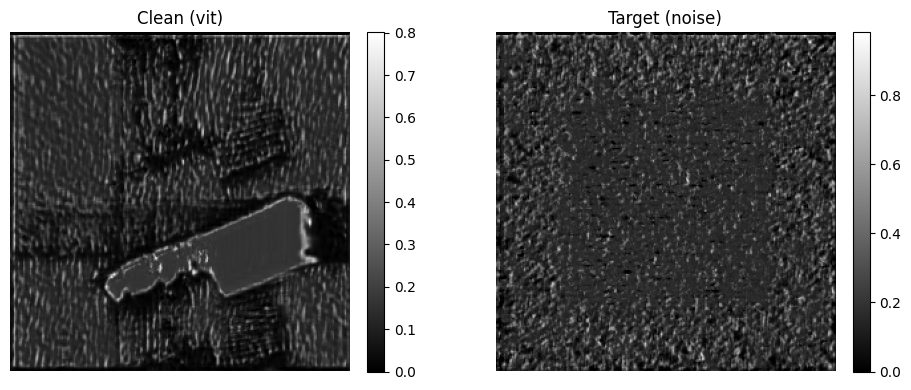

In [12]:
import os
import torch
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.io import loadmat

# -----------------------------
# Paths / run configuration
# -----------------------------
data_dir         = os.path.join(os.getcwd(), "data")          # model weights, D.mat, etc.
raw_sar_data_dir = os.path.join(os.getcwd(), "raw_sar_data")  # holds knife.mat, plier.mat, ...

mfa_or_vit  = "vit"     # "mfa" or "vit"
target_mode = "noise"  # "noise" or "object"


target_raw_select = 9   # target: 1..10 (used only if target_mode == "object")

rawData_select    = 10   # victim: 1..10

# Dataset names (must match .mat filenames in raw_sar_data_dir)
rawData = [
    "knife",                 # 1
    "plier",                 # 2
    "scissor",               # 3
    "screw_driver",          # 4
    "sharp_paint_speader",   # 5
    "dragger",               # 6
    "wrench",                # 7
    "gun",                   # 8
    "rifle",                 # 9
    "butcher_knife",               # 10
]


VICTIM_GEOM = {
    "knife":               (1.0, 1.0, 185.0, 5_000_000.0),
    "plier":               (1.0, 2.0, 210.0, 5_000_000.0),
    "scissor":             (1.0, 2.0, 215.0, 5_000_000.0),
    "screw_driver":        (1.0, 2.0, 230.0, 5_000_000.0),
    "sharp_paint_speader": (1.0, 2.0, 180.0, 5_000_000.0),
    "dragger":             (1.0, 2.0, 195.0, 5_000_000.0),

    # MATLAB special case:
    "wrench":              (1.0, 1.0, 170.0, 9_121_000.0),

    "gun":                 (1.0, 1.0, 185.0, 9_121_000.0),
    "rifle":               (1.0, 1.0, 185.0, 9_121_000.0),
    "butcher_knife":             (1.0, 2.0, 210.0, 5_000_000.0),
}

TARGET_GEOM = {
    "knife":               (1.0, 1.0, 185.0, 5_000_000.0),
    "plier":               (1.0, 2.0, 220.0, 5_000_000.0),

    # MATLAB target says scissor z0_tgt = 215
    "scissor":             (1.0, 2.0, 215.0, 5_000_000.0),

    "screw_driver":        (1.0, 2.0, 230.0, 5_000_000.0),
    "sharp_paint_speader": (1.0, 2.0, 180.0, 5_000_000.0),
    "dragger":             (1.0, 2.0, 195.0, 5_000_000.0),

    # MATLAB special case:
    "wrench":              (1.0, 1.0, 180.0, 9_121_000.0),

    # MATLAB target for gun: (dx_t=1, dy_t=2, z0_tgt=185)
    "gun":                 (1.0, 1.0, 185.0, 9_121_000.0),

    "rifle":               (1.0, 1.0, 185.0, 9_121_000.0),
    "butcher_knife":             (1.0, 2.0, 210.0, 5_000_000.0),
}

# -----------------------------
# Load trained ViT model
# -----------------------------
model = HFFH_ViT(img_channels=1, patch_size=(4, 4), dropout=0.0).to(device)
model.load_state_dict(
    torch.load(os.path.join(data_dir, "hffh_vit_ch1_best_epoch_015.pth"), map_location=device)
)
model.eval()

# -----------------------------
# Load victim data
# -----------------------------
victim_name = rawData[rawData_select - 1]
victim_path = os.path.join(raw_sar_data_dir, f"{victim_name}.mat")

raw_cube = torch.as_tensor(
    sio.loadmat(victim_path)["adcDataCube"],
    device=device
).to(torch.complex64)

Nsamp, M, N = raw_cube.shape
Np = M*N

# --- MATLAB-matched victim geometry (including FS) ---
if victim_name not in VICTIM_GEOM:
    raise ValueError(f"Unknown victim selection: {victim_name}")
dx, dy, z0_mm, FS_v = VICTIM_GEOM[victim_name]

print(
    f"victim={victim_name} | raw_cube shape: {tuple(raw_cube.shape)} | "
    f"dx={dx} dy={dy} z0_mm={z0_mm} FS={FS_v/1e6:.3f} MHz"
)

params = MFAParams(
    F0        = 77e9,
    c0        = 3e8,
    dx        = float(dx),
    dy        = float(dy),
    z0_mm     = float(z0_mm),
    bbox      = (-200.0, 200.0, -200.0, 200.0),
    FS        = float(FS_v),            # <-- UPDATED: MATLAB-style FS
    K0        = 70.295e12,
    tI        = 4.5225e-10,
    nFFTtime  = 1024,
    nFFTspace = 1024,
)

# -------------------------------
# CLEAN image (forward pass #1)
# -------------------------------
with torch.no_grad():
    clean_img = victim_forward(raw_cube, params, model, mfa_or_vit)  # (1,1,H,W)


# -------------------------------
# TARGET image (forward pass #2)
# -------------------------------
if target_mode.lower() == "noise":
    # Keep your old noise behavior (minimal change):
    # shuffle across aperture for each fast-time sample
    Np = M * N
    g = torch.Generator(device=raw_cube.device).manual_seed(42)

    raw_flat = raw_cube.reshape(Nsamp, Np)
    raw_shuf = raw_flat.clone()
    for t in range(Nsamp):
        perm = torch.randperm(Np, generator=g, device=raw_cube.device)
        raw_shuf[t] = raw_shuf[t, perm]
    raw_shuf = raw_shuf.reshape(Nsamp, M, N)

    with torch.no_grad():
        target_img = victim_forward(raw_shuf, params, model, mfa_or_vit)

elif target_mode.lower() == "object":
    target_name = rawData[target_raw_select - 1]
    target_path = os.path.join(raw_sar_data_dir, f"{target_name}.mat")

    raw_cube_tgt = torch.as_tensor(
        sio.loadmat(target_path)["adcDataCube"],
        device=device
    ).to(torch.complex64)

    print(f"target={target_name} | raw_cube_tgt shape: {tuple(raw_cube_tgt.shape)}")

    # --- MATLAB-matched target geometry (including FS) ---
    if target_name not in TARGET_GEOM:
        raise ValueError(f"Unknown target selection: {target_name}")
    dx_t, dy_t, z0_t_mm, FS_t = TARGET_GEOM[target_name]

    params_tgt = MFAParams(
        F0        = params.F0,
        c0        = params.c0,
        dx        = float(dx_t),
        dy        = float(dy_t),
        z0_mm     = float(z0_t_mm),
        bbox      = params.bbox,
        FS        = float(FS_t),         # <-- UPDATED: MATLAB-style target FS
        K0        = params.K0,
        tI        = params.tI,
        nFFTtime  = params.nFFTtime,
        nFFTspace = params.nFFTspace,
    )

    print(
        f"target params: dx={params_tgt.dx}, dy={params_tgt.dy}, "
        f"z0_mm={params_tgt.z0_mm}, FS={params_tgt.FS/1e6:.3f} MHz"
    )

    with torch.no_grad():
        target_img = victim_forward(raw_cube_tgt, params_tgt, model, mfa_or_vit)

else:
    raise ValueError("target_mode must be 'noise' or 'object'.")

# If output sizes differ, resize target to match clean for plotting/comparisons
if target_img.shape != clean_img.shape:
    target_img = F.interpolate(
        target_img,
        size=clean_img.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

# ------------------------------------------------------------
# ViT version: Load D_1 / D_2 and build D_aa, then sample to D_t
# EXACTLY mirrors your MATLAB branching + rng behavior
# ------------------------------------------------------------

# ---- Load D_1 (required)
D1_np = loadmat(os.path.join(data_dir, "D_1.mat"))["D"]  # (Nsamp_pool, K1)
D_1_t = torch.as_tensor(D1_np.astype(np.complex64), dtype=torch.complex64, device=device)

# ---- Load D_2 (optional)
D_2_t = None
d2_path = os.path.join(data_dir, "D_2.mat")
if os.path.exists(d2_path):
    D2_np = loadmat(d2_path)["D"]  # (Nsamp_pool, K2)
    D_2_t = torch.as_tensor(D2_np.astype(np.complex64), dtype=torch.complex64, device=device)


if (Nsamp == 512) and ((M * N) > 40000) and (D_2_t is not None):
    D_temp = torch.cat([D_1_t, D_2_t], dim=0)      # stack rows
    D_aa   = torch.cat([D_temp, D_temp], dim=1)    # tile cols (duplicate columns)

elif (Nsamp == 512) and ((M * N) == 40000) and (D_2_t is not None):
    D_aa = torch.cat([D_1_t, D_2_t], dim=0)        # stack rows

else:
    D_aa = D_1_t

# ------------------------------------------------------------
# Sample columns to build D_pool, then pick one column per aperture
#   targetK = M*N
#   rng(0)
#   sample_idx = randi(size(D_aa,2), [1,targetK])
#   D_pool = D_aa(:, sample_idx)           -> (Nsamp_pool, targetK)
#   sel_idx  = randi(size(D_pool,2), [1,Np])
#   D_t      = D_pool(:, sel_idx)          -> (Nsamp_pool, Np)
# ------------------------------------------------------------
targetK = M * N

# MATLAB rng(0) equivalent for this usage pattern (deterministic)
rng = np.random.default_rng(0)

K_pool = D_aa.shape[1]
sample_idx = rng.integers(low=0, high=K_pool, size=targetK, endpoint=False)
D_pool = D_aa[:, sample_idx]                       # (Nsamp_pool, targetK)
sel_idx = rng.integers(low=0, high=D_pool.shape[1], size=Np, endpoint=False)
D_t = D_pool[:, sel_idx]                              # (Nsamp_pool, Np)

# ---- Make it match (Nsamp, M, N) for ViT A(m,n) attack ----
# Use first Nsamp rows if pool has more rows (common)
if D_t.shape[0] < Nsamp:
    raise RuntimeError(f"D_t has fewer rows than Nsamp: {D_t.shape[0]} < {Nsamp}")
D_t = D_t[:Nsamp, :]                                  # (Nsamp, Np)

D_cube = D_t.reshape(Nsamp, M, N)                     # (Nsamp, M, N)

print(f"[D] D_t shape   : {tuple(D_t.shape)} (Nsamp, Np)")
print(f"[D] D_cube shape: {tuple(D_cube.shape)} (Nsamp, M, N)")



#sel_idx = rng.integers(low=0, high=D_pool.shape[1], size=Np, endpoint=False)
#D_cube = D_pool[:, sel_idx]                           # (Nsamp_pool, Np)

print(f"[D] D_1 shape   : {tuple(D_1_t.shape)}")
print(f"[D] D_2 shape   : {None if D_2_t is None else tuple(D_2_t.shape)}")
print(f"[D] D_aa shape  : {tuple(D_aa.shape)}")
print(f"[D] D_pool shape: {tuple(D_pool.shape)} (Nsamp_pool, targetK)")
print(f"[D] D_t shape   : {tuple(D_cube.shape)} (Nsamp_pool, Np)")


print("clean_img  |.| min/max:", clean_img.abs().min().item(), "/", clean_img.abs().max().item())
print("target_img |.| min/max:", target_img.abs().min().item(), "/", target_img.abs().max().item())
print("clean_img :", tuple(clean_img.shape), clean_img.dtype, clean_img.device)
print("target_img:", tuple(target_img.shape), target_img.dtype, target_img.device)

# ---- quick visualization
clean2d  = clean_img.detach().abs().squeeze().cpu().numpy()
target2d = target_img.detach().abs().squeeze().cpu().numpy()

plt.figure(figsize=(10, 4))

ax1 = plt.subplot(1, 2, 1)
im1 = ax1.imshow(clean2d, cmap="gray", origin="lower")
ax1.set_title("Clean (vit)")
ax1.axis("off")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = plt.subplot(1, 2, 2)
im2 = ax2.imshow(target2d, cmap="gray", origin="lower")
ax2.set_title(f"Target ({target_mode})")
ax2.axis("off")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Random Weight Attack 

In [13]:
# ============================================================
# RANDOM-WEIGHT ATTACK SWEEP
# For MFA / HFFH_ViT victim pipeline
# ============================================================

import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

EPS = 1e-12

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
num_trials = 20
candidate_PaPr_dB = [10]  #list(range(0, 21))   # 0:20
success_ssim_thresh = 0.001
success_rate_thresh = 0.01
random_weight_mode = "complex_gaussian"   # "complex_gaussian" or "unit_modulus"
show_extra_examples = False

# ------------------------------------------------------------
# Normalize clean / target once, same style as your newer code
# ------------------------------------------------------------
global_scale = clean_img.abs().amax() + EPS
clean_img = clean_img / global_scale
target_img = target_img / global_scale

# ------------------------------------------------------------
# Helper: reconstruct attacked image from random A
# A is over aperture grid (M,N), like your ViT optimization code
# ------------------------------------------------------------
def reconstruct_adv_image_random_vit(
    raw_cube,
    D_cube,
    A_rand,
    params,
    model,
    mfa_or_vit,
    global_scale,
):
    """
    raw_cube : (Nsamp,M,N) complex
    D_cube   : (Nsamp,M,N) complex
    A_rand   : (M,N) complex

    returns:
      adv_img      : (1,1,H,W)
      PaPr_final   : scalar
      PaPr_final_dB: scalar
    """
    delta = D_cube * A_rand.unsqueeze(0)     # (Nsamp,M,N)
    raw_adv = raw_cube + delta               # (Nsamp,M,N)

    with torch.no_grad():
        adv_img = victim_forward(raw_adv, params, model, mfa_or_vit)
        adv_img = adv_img / (global_scale + EPS)

        Pa = (torch.linalg.norm(delta) ** 2).item()
        Pr = (torch.linalg.norm(raw_cube) ** 2).item() + EPS
        PaPr = Pa / Pr
        PaPr_dB = 10.0 * math.log10(PaPr + EPS)

    return adv_img, PaPr, PaPr_dB


# ------------------------------------------------------------
# Helper: compare adversarial image to clean image
# ------------------------------------------------------------
def compare_to_clean(adv_img, clean_img):
    """
    adv_img, clean_img: (1,1,H,W) torch tensors
    returns: mse_AC, ncc_AC, ssim_AC, psnr_AC
    """
    with torch.no_grad():
        mse_AC = F.mse_loss(adv_img, clean_img).item()

        a = adv_img.reshape(-1)
        c = clean_img.reshape(-1)

        ncc_num = torch.sum(a * c)
        ncc_den = torch.sqrt(torch.sum(a**2) * torch.sum(c**2) + EPS)
        ncc_AC = (ncc_num / ncc_den).item()

        adv2d = adv_img.detach().abs().squeeze().cpu().numpy()
        cln2d = clean_img.detach().abs().squeeze().cpu().numpy()

        data_range_C = float(cln2d.max() - cln2d.min()) + EPS
        ssim_AC = ssim(adv2d, cln2d, data_range=data_range_C)
        psnr_AC = psnr(cln2d, adv2d, data_range=data_range_C)

    return mse_AC, ncc_AC, ssim_AC, psnr_AC


# ------------------------------------------------------------
# Power reference
# ------------------------------------------------------------
Pr_ref = (torch.linalg.norm(raw_cube) ** 2).item() + EPS

print("\n============================================================")
print(f"Random-weight concealment sweep for {mfa_or_vit} on {victim_name}")
print(f"Trials per budget: {num_trials}")
print(f"Success criterion: SSIM(A,C) <= {success_ssim_thresh:.3f}")
print(f"Required success rate: {success_rate_thresh:.2f}")
print("============================================================\n")

all_budget_results = []

best_budget_found = False
chosen_budget_idx = None

# ------------------------------------------------------------
# Sweep over candidate Pa/Pr budgets
# ------------------------------------------------------------
for b_idx, target_PaPr_dB in enumerate(candidate_PaPr_dB):
    target_PaPr = 10 ** (target_PaPr_dB / 10.0)

    psnr_AC_trials = np.zeros(num_trials, dtype=np.float64)
    ssim_AC_trials = np.zeros(num_trials, dtype=np.float64)
    ncc_AC_trials  = np.zeros(num_trials, dtype=np.float64)
    pa_pr_trials   = np.zeros(num_trials, dtype=np.float64)
    mse_AC_trials  = np.zeros(num_trials, dtype=np.float64)

    success_flags = np.zeros(num_trials, dtype=bool)

    adv_imgs_trial = []
    A_store_trial  = []

    print(f"Testing budget Pa/Pr = {target_PaPr_dB:.2f} dB ...")

    for tr in range(num_trials):
        rng_local = np.random.default_rng(10000 + 100 * (b_idx + 1) + (tr + 1))

        # ----------------------------------------------------
        # Draw random complex weights over aperture grid (M,N)
        # ----------------------------------------------------
        if random_weight_mode.lower() == "complex_gaussian":
            A_re = rng_local.standard_normal((M, N))
            A_im = rng_local.standard_normal((M, N))
            A_rand_np = A_re + 1j * A_im

        elif random_weight_mode.lower() == "unit_modulus":
            theta = 2 * np.pi * rng_local.random((M, N))
            A_rand_np = np.exp(1j * theta)

        else:
            raise ValueError("Unknown random_weight_mode.")

        A_rand = torch.tensor(A_rand_np.astype(np.complex64), device=device)

        # ----------------------------------------------------
        # Scale to satisfy target Pa/Pr
        # ----------------------------------------------------
        delta_rand = D_cube * A_rand.unsqueeze(0)
        Pa_rand = (torch.linalg.norm(delta_rand) ** 2).item()

        scale_pow = math.sqrt((target_PaPr * Pr_ref) / (Pa_rand + EPS))
        A_rand = A_rand * scale_pow

        # ----------------------------------------------------
        # Reconstruct attacked image
        # ----------------------------------------------------
        adv_img, PaPr_final, _ = reconstruct_adv_image_random_vit(
            raw_cube=raw_cube,
            D_cube=D_cube,
            A_rand=A_rand,
            params=params,
            model=model,
            mfa_or_vit=mfa_or_vit,
            global_scale=global_scale,
        )

        # ----------------------------------------------------
        # Metrics against clean image
        # ----------------------------------------------------
        mse_AC, ncc_AC, ssim_AC, psnr_AC = compare_to_clean(adv_img, clean_img)

        mse_AC_trials[tr] = mse_AC
        ncc_AC_trials[tr] = ncc_AC
        ssim_AC_trials[tr] = ssim_AC
        psnr_AC_trials[tr] = psnr_AC
        pa_pr_trials[tr] = PaPr_final

        success_flags[tr] = (ssim_AC <= success_ssim_thresh)

        adv_imgs_trial.append(adv_img.detach().clone())
        A_store_trial.append(A_rand.detach().clone())

    success_rate = np.mean(success_flags)

    print(f"  PSNR(A,C): {psnr_AC_trials.mean():.2f} ± {psnr_AC_trials.std():.2f} dB")
    print(f"  SSIM(A,C): {ssim_AC_trials.mean():.4f} ± {ssim_AC_trials.std():.4f}")
    print(f"  NCC(A,C) : {ncc_AC_trials.mean():.4f} ± {ncc_AC_trials.std():.4f}")
    print(f"  Pa/Pr    : {pa_pr_trials.mean():.4e} ± {pa_pr_trials.std():.4e} (linear)")
    print(f"  Success rate (SSIM<={success_ssim_thresh:.3f}): {success_rate:.2f}\n")

    result = {
        "PaPr_dB": target_PaPr_dB,
        "PaPr_lin": float(pa_pr_trials.mean()),
        "psnr_AC_mean": float(psnr_AC_trials.mean()),
        "psnr_AC_std": float(psnr_AC_trials.std()),
        "ssim_AC_mean": float(ssim_AC_trials.mean()),
        "ssim_AC_std": float(ssim_AC_trials.std()),
        "ncc_AC_mean": float(ncc_AC_trials.mean()),
        "ncc_AC_std": float(ncc_AC_trials.std()),
        "mse_AC_mean": float(mse_AC_trials.mean()),
        "mse_AC_std": float(mse_AC_trials.std()),
        "success_rate": float(success_rate),
        "adv_imgs": adv_imgs_trial,
        "A_store": A_store_trial,
        "success_flags": success_flags.copy(),
        "psnr_AC_trials": psnr_AC_trials.copy(),
        "ssim_AC_trials": ssim_AC_trials.copy(),
        "ncc_AC_trials": ncc_AC_trials.copy(),
        "pa_pr_trials": pa_pr_trials.copy(),
    }
    all_budget_results.append(result)

    if (not best_budget_found) and (success_rate >= success_rate_thresh):
        best_budget_found = True
        chosen_budget_idx = b_idx

# ------------------------------------------------------------
# Choose operating budget
# ------------------------------------------------------------
if best_budget_found:
    print(f"Chosen smallest successful budget: {all_budget_results[chosen_budget_idx]['PaPr_dB']:.2f} dB")
else:
    chosen_budget_idx = len(all_budget_results) - 1
    print("No budget met success-rate criterion.")
    print(f"Using strongest tested budget: {all_budget_results[chosen_budget_idx]['PaPr_dB']:.2f} dB")

chosen = all_budget_results[chosen_budget_idx]

succ_idx = np.where(chosen["success_flags"])[0]
if len(succ_idx) > 0:
    ord_idx = np.argsort(chosen["ssim_AC_trials"][succ_idx])
    pick = succ_idx[ord_idx[max(0, round(len(ord_idx) / 2) - 1)]]
else:
    pick = int(np.argmin(chosen["ssim_AC_trials"]))

adv_img_best = chosen["adv_imgs"][pick]
A_best       = chosen["A_store"][pick]


Random-weight concealment sweep for vit on butcher_knife
Trials per budget: 20
Success criterion: SSIM(A,C) <= 0.001
Required success rate: 0.01

Testing budget Pa/Pr = 10.00 dB ...
  PSNR(A,C): 14.59 ± 0.09 dB
  SSIM(A,C): 0.1229 ± 0.0061
  NCC(A,C) : 0.6637 ± 0.0051
  Pa/Pr    : 1.0000e+01 ± 9.8403e-07 (linear)
  Success rate (SSIM<=0.001): 0.00

No budget met success-rate criterion.
Using strongest tested budget: 10.00 dB


## Evaluations


FINAL TABLE NUMBERS for vit on butcher_knife
Use budget: 10.00 dB
PSNR(A,C): 14.59 ± 0.09 dB
SSIM(A,C): 0.1229 ± 0.0061
Pa/Pr     : 10.0000 (linear mean), 10.0000 dB


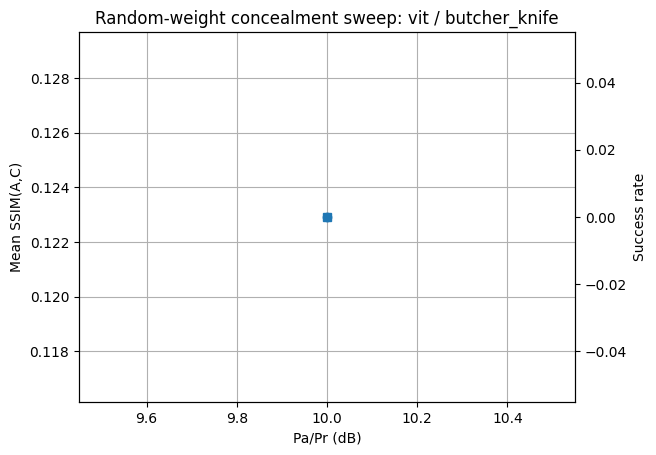

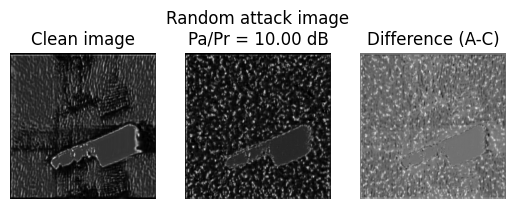

In [14]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n============================================================")
print(f"FINAL TABLE NUMBERS for {mfa_or_vit} on {victim_name}")
print(f"Use budget: {chosen['PaPr_dB']:.2f} dB")
print(f"PSNR(A,C): {chosen['psnr_AC_mean']:.2f} ± {chosen['psnr_AC_std']:.2f} dB")
print(f"SSIM(A,C): {chosen['ssim_AC_mean']:.4f} ± {chosen['ssim_AC_std']:.4f}")

PaPr_lin_mean = chosen["PaPr_lin"]
PaPr_dB_mean  = 10.0 * math.log10(PaPr_lin_mean + EPS)
print(f"Pa/Pr     : {PaPr_lin_mean:.4f} (linear mean), {PaPr_dB_mean:.4f} dB")
print("============================================================")

# ============================================================
# BUDGET SWEEP FIGURE
# ============================================================
plt.figure()

xvals = [r["PaPr_dB"] for r in all_budget_results]
ssim_means = [r["ssim_AC_mean"] for r in all_budget_results]
succ_rates = [r["success_rate"] for r in all_budget_results]

ax1 = plt.gca()
ax1.plot(xvals, ssim_means, "-o", linewidth=1.5)
ax1.set_ylabel("Mean SSIM(A,C)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(xvals, succ_rates, "-s", linewidth=1.5)
ax2.set_ylabel("Success rate")

ax1.set_xlabel("Pa/Pr (dB)")
plt.title(f"Random-weight concealment sweep: {mfa_or_vit} / {victim_name}")
plt.show()

# ============================================================
# QUALITATIVE FIGURE
# ============================================================
adv2d = adv_img_best.detach().abs().squeeze().cpu().numpy()
cln2d = clean_img.detach().abs().squeeze().cpu().numpy()

clean2d = cln2d
adv2d_v = adv2d
diff2d  = adv2d_v - clean2d

plt.figure()

plt.subplot(1, 3, 1)
plt.imshow(clean2d, cmap="gray", origin="lower")
plt.title("Clean image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adv2d_v, cmap="gray", origin="lower")
plt.title(f"Random attack image\nPa/Pr = {chosen['PaPr_dB']:.2f} dB")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(diff2d, cmap="gray", origin="lower")
plt.title("Difference (A-C)")
plt.axis("off")

plt.show()